In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [55]:
df = pd.read_csv('Downloads/tips.csv')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [59]:
df['smoker'].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [61]:
df['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [63]:
df['time'].value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [75]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [77]:
df.duplicated().sum()

1

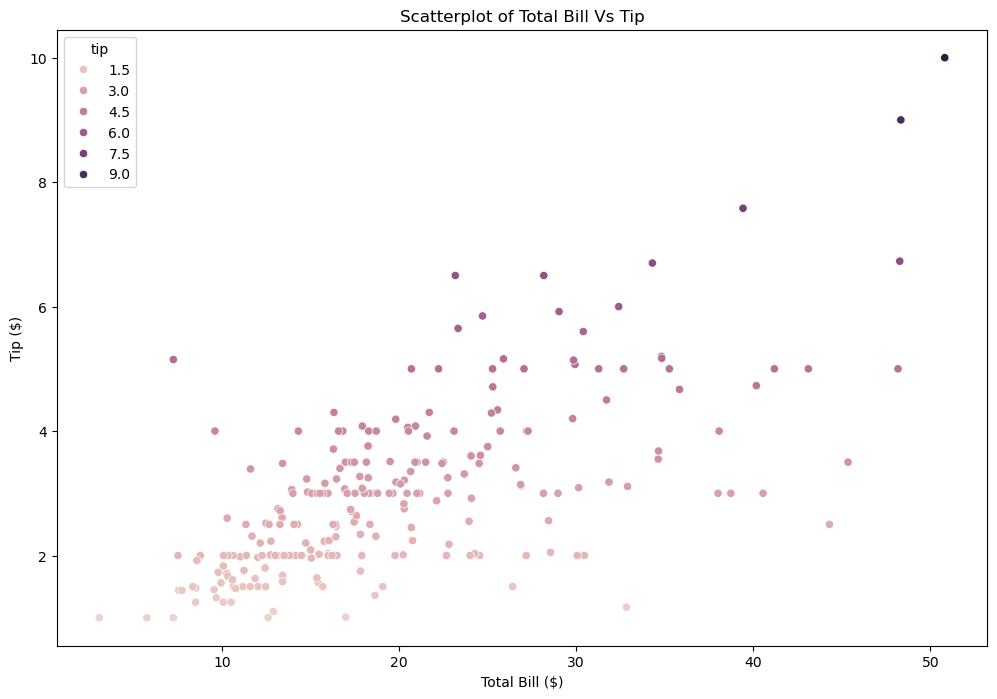

In [83]:
plt.figure(figsize=(12,8))
sns.scatterplot(x='total_bill', y='tip', data=df, hue='tip')
plt.title('Scatterplot of Total Bill Vs Tip')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.show()

Text(0.5, 1.0, 'Boxplot of Size')

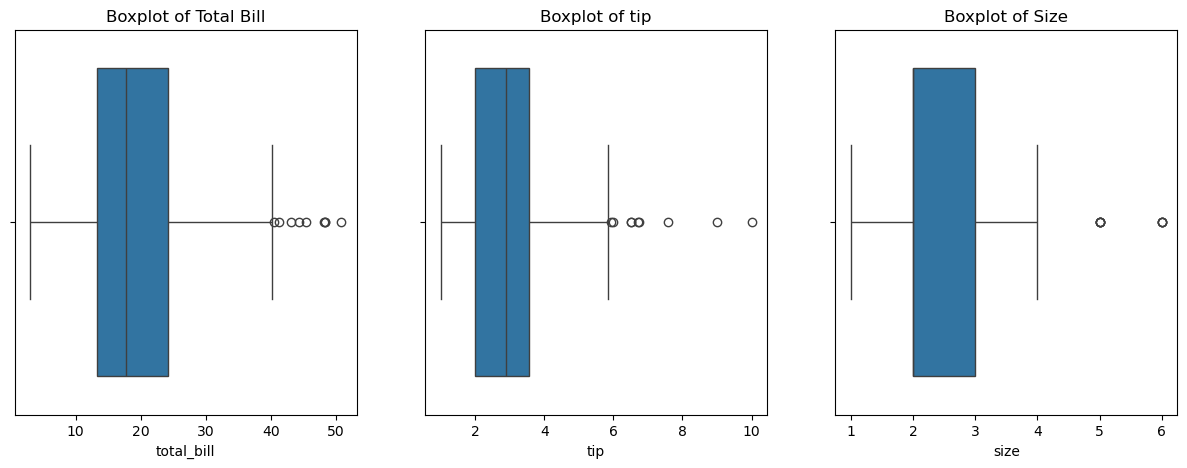

In [85]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(x='total_bill', data=df)
plt.title('Boxplot of Total Bill')

plt.subplot(1,3,2)
sns.boxplot(x='tip', data=df)
plt.title('Boxplot of tip')

plt.subplot(1,3,3)
sns.boxplot(x='size', data=df)
plt.title('Boxplot of Size')

In [87]:
# Calculate Q1, Q3, and IQR
Q1 = df[['total_bill', 'tip', 'size']].quantile(0.25)
Q3 = df[['total_bill', 'tip', 'size']].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Capping outliers
df_capped = df.copy()
df_capped[['total_bill', 'tip', 'size']] = df_capped[['total_bill', 'tip', 'size']].clip(
    lower=lower_limit,
    upper=upper_limit,
    axis=1
)

print("Shape of original dataframe:", df.shape)
print("Shape of dataframe after capping outliers:", df_capped.shape)


Shape of original dataframe: (244, 7)
Shape of dataframe after capping outliers: (244, 7)


In [89]:
df['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [91]:
# One-Hot Encode 'day'
df = pd.get_dummies(df, columns=['day'], drop_first=True)

df.head()


,total_bill,tip,sex,smoker,time,size,day_Sat,day_Sun,day_Thur
0,16.99,1.01,Female,No,Dinner,2,False,True,False
1,10.34,1.66,Male,No,Dinner,3,False,True,False
2,21.01,3.50,Male,No,Dinner,3,False,True,False
3,23.68,3.31,Male,No,Dinner,2,False,True,False
4,24.59,3.61,Female,No,Dinner,4,False,True,False


In [93]:
df = pd.get_dummies(df, columns=['sex'], drop_first=True)
df.head()

,total_bill,tip,smoker,time,size,day_Sat,day_Sun,day_Thur,sex_Male
0,16.99,1.01,No,Dinner,2,False,True,False,False
1,10.34,1.66,No,Dinner,3,False,True,False,True
2,21.01,3.50,No,Dinner,3,False,True,False,True
3,23.68,3.31,No,Dinner,2,False,True,False,True
4,24.59,3.61,No,Dinner,4,False,True,False,False


In [95]:
df = pd.get_dummies(df, columns=['smoker'], drop_first=True)
df = pd.get_dummies(df, columns=['time'], drop_first=True)
df.head()

,total_bill,tip,size,day_Sat,day_Sun,day_Thur,sex_Male,smoker_Yes,time_Lunch
0,16.99,1.01,2,False,True,False,False,False,False
1,10.34,1.66,3,False,True,False,True,False,False
2,21.01,3.50,3,False,True,False,True,False,False
3,23.68,3.31,2,False,True,False,True,False,False
4,24.59,3.61,4,False,True,False,False,False,False


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   size        244 non-null    int64  
 3   day_Sat     244 non-null    bool   
 4   day_Sun     244 non-null    bool   
 5   day_Thur    244 non-null    bool   
 6   sex_Male    244 non-null    bool   
 7   smoker_Yes  244 non-null    bool   
 8   time_Lunch  244 non-null    bool   
dtypes: bool(6), float64(2), int64(1)
memory usage: 7.3 KB


In [101]:
X = df.drop('tip', axis=1)
Y = df['tip']

In [103]:
# Spliting the data.
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [107]:
# Training the model 
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [109]:
y_pred = model.predict(X_test)

In [115]:
# Evaluating the model.
from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)

print(f"R-squared: {r2:.2f}")
print(f"Mean Squared Error: {mse:.2f}")

R-squared: 0.44
Mean Squared Error: 0.70
